## 1. Data Import & Initial Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Finding Missing Values

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Age column contained missing values. Missing values were replaced using the mean age of passengers.

In [11]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 1.Univariate Analysis

## Age

### Conclusion

* **Two Main Groups:** The data hits a peak twice—first with a huge group of babies and toddlers (ages 0 to 5), and again with a large group of young adults (ages 20 to 35).

* **Mostly Young People:** The vast majority of the people in this dataset are on the younger side.

* **Fewer Older People:** The numbers drop off drastically as age increases. There are very few middle-aged people and almost no elderly individuals.

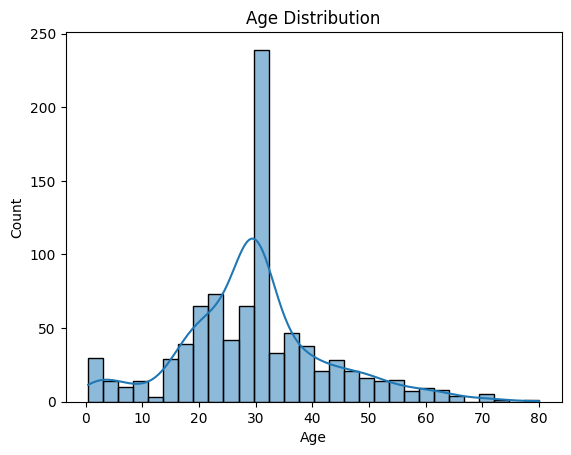

In [13]:
sns.histplot(df['Age'],kde=True)
plt.title('Age Distribution')
plt.show()

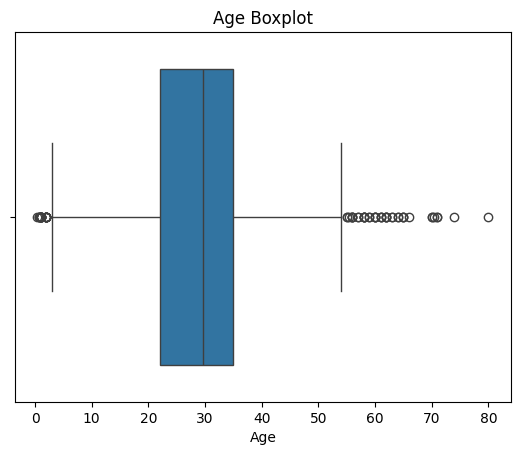

In [14]:
sns.boxplot(x=df['Age'])
plt.title('Age Boxplot')
plt.show()

# Fare

### Conclusion

* **Cheap Tickets Dominate:** The vast majority of passengers paid a very low fare (under 50).

* **Extreme Price Range:** While most tickets were cheap, a few rare tickets were incredibly expensive, creating a long tail in the data.

* **Presence of Outliers:** The boxplot clearly shows many high-value outliers, including an extreme case where a fare exceeded 500.

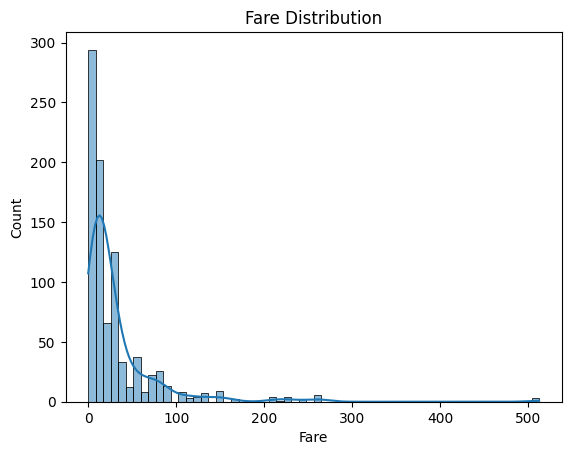

In [15]:
sns.histplot(df['Fare'],kde=True)
plt.title('Fare Distribution')
plt.show()

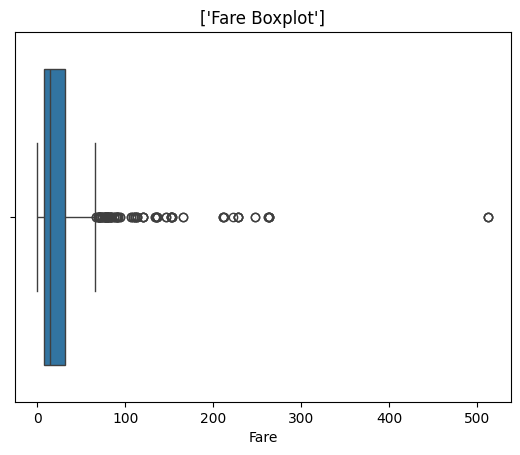

In [16]:
sns.boxplot(x=df['Fare'])
plt.title(['Fare Boxplot'])
plt.show()

# Survived

### Conclusion

More Deaths Than Survival: The majority of the passengers (61.6%) did not survive the disaster, while only 38.4% managed to survive.

Imbalanced Outcomes: The bar graph visually highlights a significant gap, showing that the number of casualties vastly outnumbered the survivors.

In [17]:
#0 = Did Not Survive (Deceased): 549 people died.
#1 = Survived: 342 people lived.

df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

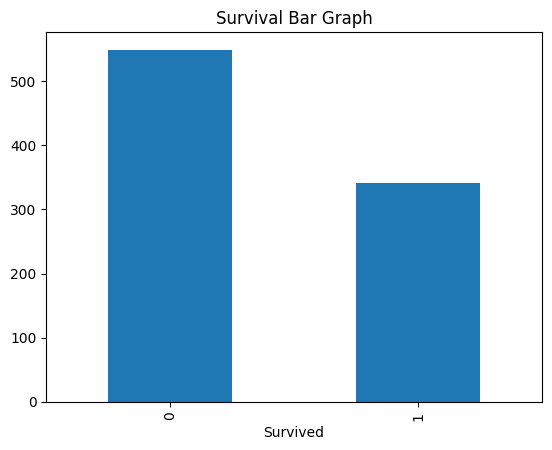

In [18]:
df['Survived'].value_counts().plot(kind ='bar')
plt.title('Survival Bar Graph')
plt.show()

Text(0.5, 1.0, 'Survival Pie Chart')

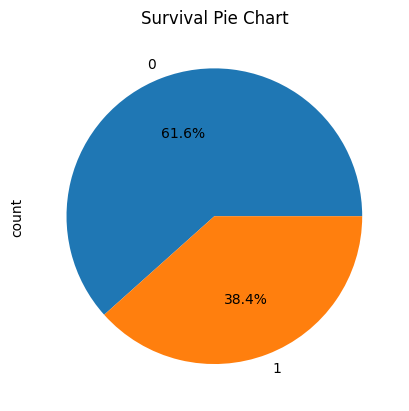

In [19]:
df['Survived'].value_counts().plot(kind ='pie',autopct = '%0.1f%%')
plt.title('Survival Pie Chart')

# Passenger Class (PClass)

### Conclusion

* **Dominance of Third Class:** The vast majority of passengers traveled in Class 3 (nearly 500 people), making it the largest group on the ship by far.

* **Fewer Luxury Passengers:** Class 1 and Class 2 had significantly lower passenger counts, hovering around 215 and 185 respectively.

* **Unequal Distribution:** There were more passengers in cheap accommodation (Class 3) than in first and second class combined.

In [20]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

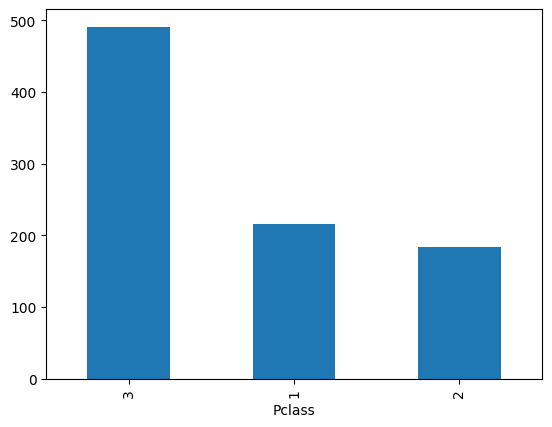

In [21]:
df['Pclass'].value_counts().plot(kind = 'bar')

# Gender Distribution(Sex)

### Conclusion

* Male Passengers are more than female Passengers.
* The Gender Distribution is not balanced

In [22]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

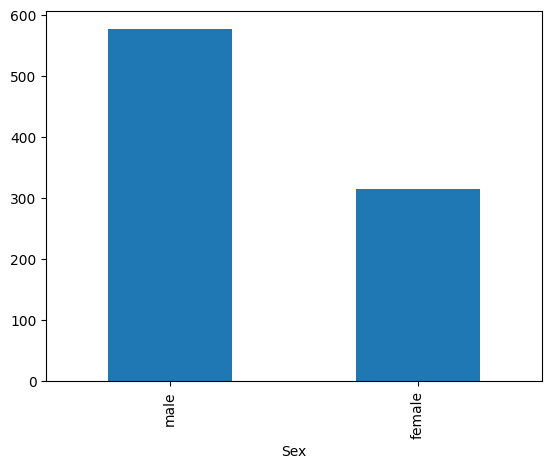

In [23]:
df['Sex'].value_counts().plot(kind = 'bar')

# Embarkation Point (Embarked)

In [24]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Text(0.5, 1.0, 'Embarked Port Distribution')

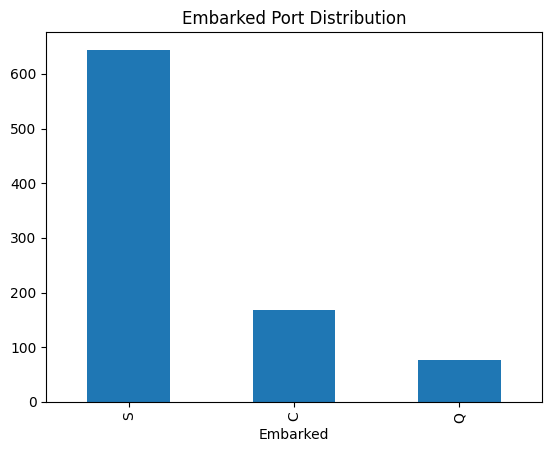

In [25]:
df['Embarked'].value_counts().plot(kind = 'bar')
plt.title('Embarked Port Distribution')

# 2.Bivariate Analysis

## Survival gender (sex)

### Conclusion

Women Survived, Most Men Did Not: The data clearly shows that women had a much higher survival rate. Over 230 women survived compared to fewer than 80 who died, while the vast majority of men (nearly 470) tragically lost their lives.

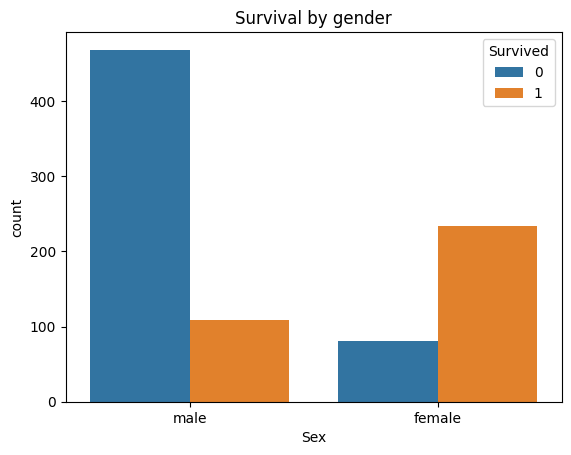

In [26]:
sns.countplot(data=df, x='Sex',hue='Survived')
plt.title('Survival by gender')
plt.show()

In [27]:
pd.crosstab(df['Sex'],df['Survived'],normalize='index') *100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


## Survival vs Passenger Class (Pclass)

### Conclusion

* ***Class Trajectory:*** The higher the passenger class, the higher the chance of survival.

* ***First Class Priority:*** Class 1 was the only group where survivors outnumbered casualties.

* ***Third Class Tragedy:*** Class 3 saw an overwhelming number of deaths (over 350), making up the largest portion of casualties on the ship.

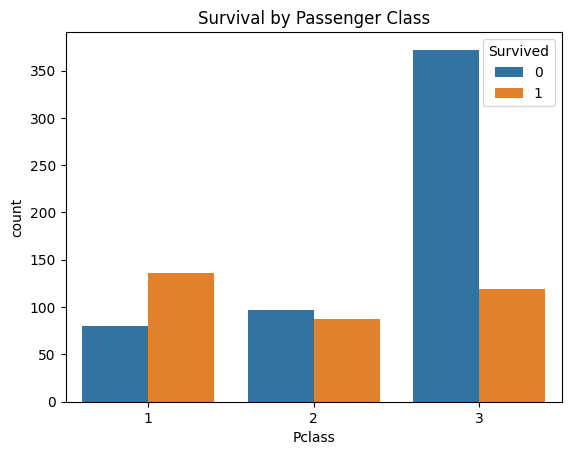

In [28]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.show()

In [29]:
pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


# Survival vs Age 

### Conclusion

* ***Priority for Children:*** Toddlers and young children (ages 0-5) had a visibly better survival rate.

* ***Heavy Losses in Mid-20s to 30s:*** The largest volume of deaths occurred among passengers aged 20-35.

* ***Similar Midpoints:*** The median age for both survivors and non-survivors is identical at 30 years old.

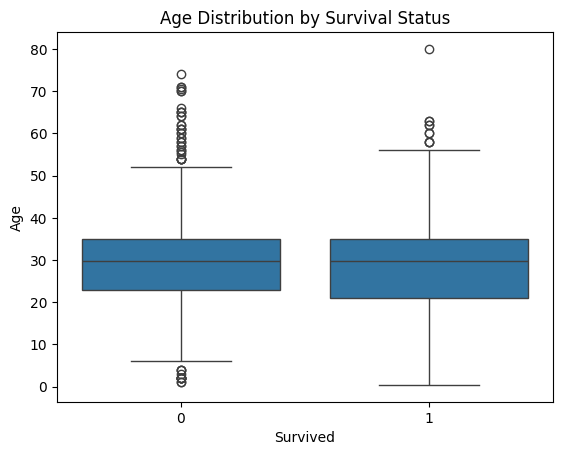

In [30]:
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age Distribution by Survival Status')
plt.show()

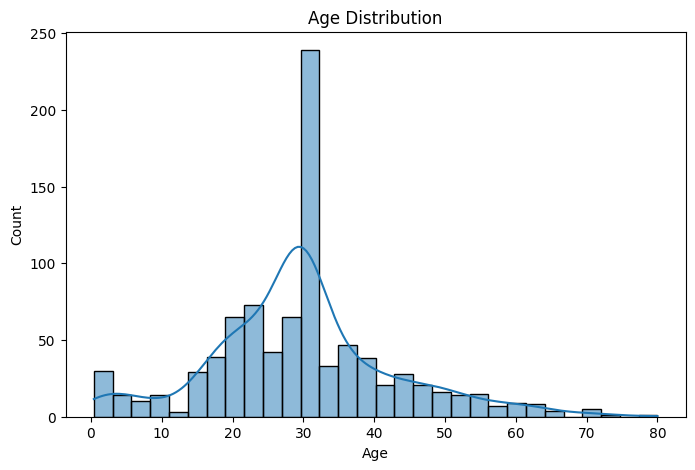

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

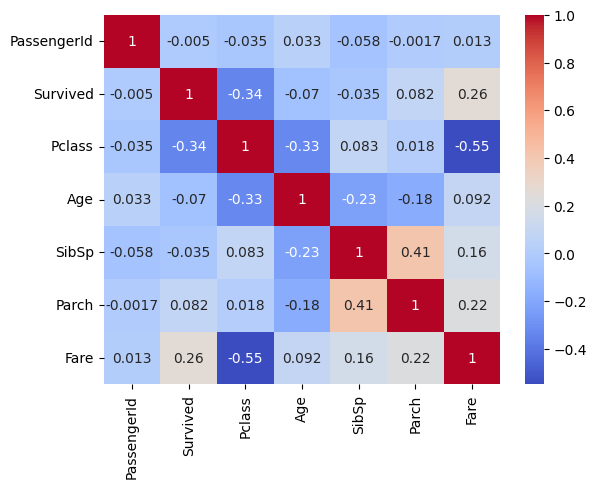

In [32]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

### Correlation Insights

- Fare has a positive relationship with survival.
- Pclass has a negative relationship with survival.
- No feature shows extremely high correlation.

# Survival vs Fare

### Conclusion

* ***Correlation with Wealth:*** Passengers who paid higher fares had a clearly visible advantage and a higher likelihood of survival.

* ***Heavy Toll on Low Fares:*** The non-survivor group (0) is heavily concentrated at the lowest fare range, showing that lower-paying passengers faced the highest risk.

* ***Extreme Outliers:*** The highest-paying passengers (including an extreme outlier over 500) are predominantly found in the survivor category.

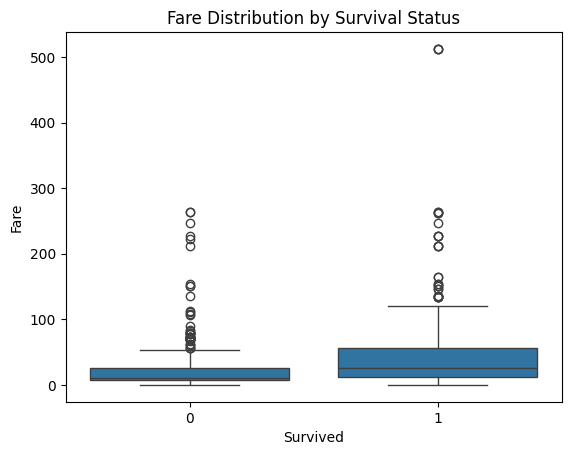

In [33]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare Distribution by Survival Status')
plt.show()

## Final Summary & Conclusion

The data shows that survival on the Titanic was not random. It was heavily driven by **gender**, **wealth**, and **age**:

* **Gender (Strongest Factor):** Women had a very high survival rate (over 230 survived), while the vast majority of men tragically died (nearly 470). This strongly reflects the "women and children first" rescue policy.
* **Class & Wealth (Money Saved Lives):** First Class was the only group where more people survived than died. Third Class was heavily overcrowded and suffered the most losses (over 350 deaths). Boxplots confirm that survivors, on average, paid much higher fares.
* **Age Priorities:** The dataset consists mostly of young people. Toddlers and young children (0–5 years) had a high survival rate, while young adults aged 20–35 made up the largest number of casualties.

### Bottom Line:
Your chances of surviving were highest if you were a **wealthy woman in First Class** and lowest if you were a **lower-income man in Third Class**.